In [ ]:
# Important Imports, System Parameters and Drive Parameters:
import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt 
import jax

# 2. Force Dynamiqs/JAX to allocate arrays on the GPU
dq.set_device("cpu")  # Use "gpu" for NVIDIA GPUs, "METAL" for Apple Silicon, or "CPU" for CPU computations


# Let's say your DGX has 4 GPUs available
num_devices = jax.device_count()
print(f"Available GPUs: {num_devices}")

dq.set_precision('double')
print(jax.devices())
# System Parameters:
params = {
    "W_c": 3030.0, 
    "Xcc" : 164.0, 
    "Kappa_c" : 0.0207,   

    "W_a": 4620.0, 
    "Xaa" : 0.0014, 
    "Kappa_a" : 0.0,

    "W_b": 7950.0, 
    "Xbb" : 0.0373, 
    "Kappa_b" : 0.984,

    "Xab" : 0.0,
    "Xac" : 0.671,
    "Xbc" : 3.538
}

# Drive Parameters:
params["Delta_c"] = 300.0
params["Delta_a"] = 18.0
params["Delta_b"] = 18.0
params["drive_amplitude_c"] = 300.0
params["drive_amplitude_a"] = 58.0
params["drive_amplitude_b"] = 48.0

# Computing steady states : 
SS_a = 2*jnp.pi*params["drive_amplitude_a"]/(1j*2*jnp.pi*params["Delta_a"]-0.5*params["Kappa_a"])
SS_b = 2*jnp.pi*params["drive_amplitude_b"]/(1j*2*jnp.pi*params["Delta_b"]-0.5*params["Kappa_b"])

# Updating Drive Amplitude Conditions :
#params["Delta_c"] = -SS_a*params["Xac"] - SS_b*params["Xbc"]
gca = jnp.abs(1+SS_a)*params["Xac"]
gcb = jnp.abs(SS_b)*params["Xbc"]

print(gca)
print(gcb)
print(jnp.abs(SS_a)**2)
print(jnp.abs(SS_b)**2)


Available GPUs: 1
[METAL(id=0)]
2.263838655202734
9.434577394544327
10.382716049382717
7.110976539111885


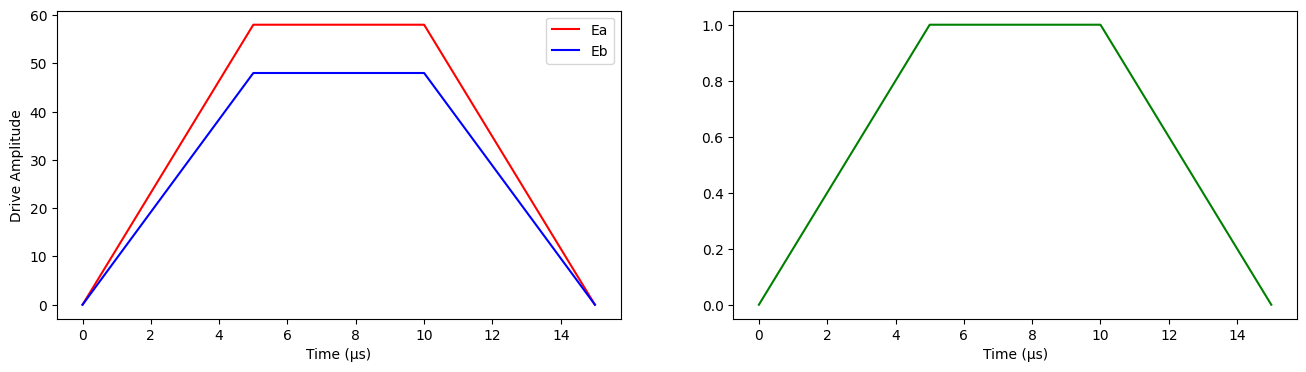

In [21]:
# Defining the System :
Na = 10
Nb = 10
Nc = 2

a = dq.destroy(Na); a=dq.tensor(a, dq.eye(Nb), dq.eye(Nc))
b = dq.destroy(Nb); b=dq.tensor(dq.eye(Na), b, dq.eye(Nc))
c = dq.destroy(Nc); c=dq.tensor(dq.eye(Na), dq.eye(Nb), c)

# Modelling the Hamiltonian in the Rotating Frame of the Drive :
H0 = -2*jnp.pi*(params["Delta_c"]*c.dag()@c + params["Delta_a"]*a.dag()@a + params["Delta_b"]*b.dag()@b 
    + 0.5*params["Xcc"]*c.dag()@c.dag()@c@c + 0.5*params["Xaa"]*a.dag()@a.dag()@a@a + 0.5*params["Xbb"]*b.dag()@b.dag()@b@b 
    + params["Xab"]*a.dag()@a@b.dag()@b + params["Xac"]*a.dag()@a@c.dag()@c + params["Xbc"]*b.dag()@b@c.dag()@c)

# Modelling the time dependent drive in a trapezoidal way :
t_ramp = 5.0      # Ramp up time in microseconds
t_total = 15.0   # Total time of the drive in microseconds

if t_total > t_ramp:
    tcorners = jnp.array([0.0, t_ramp, t_total - t_ramp, t_total])
    Ea_corners = jnp.array([0.0, params["drive_amplitude_a"], params["drive_amplitude_a"], 0.0])
    Eb_corners = jnp.array([0.0, params["drive_amplitude_b"], params["drive_amplitude_b"], 0.0])
    Ec_corners = jnp.array([0.0, params["drive_amplitude_c"], params["drive_amplitude_c"], 0.0])
else:
    tcorners = jnp.array([0.0, t_total])
    Ea_corners = jnp.array([0.0, params["drive_amplitude_a"]])
    Eb_corners = jnp.array([0.0, params["drive_amplitude_b"]])
    Ec_corners = jnp.array([0.0, params["drive_amplitude_c"]])

# --- 2. Define the THREE Time-Dependent Functions ---
# These are extremely lightweight and fast for the solver to call at every time 't'
def env_a(t): return jnp.interp(t, tcorners, Ea_corners)
def env_b(t): return jnp.interp(t, tcorners, Eb_corners)
def env_c(t): return jnp.interp(t, tcorners, Ec_corners)

# --- 3. Build the Quantum Operators ---
# (Replace these with your actual jump/drive operators for modes a, b, and c)
op_a = 1j*(a.dag() - a)
op_b = 1j*(b.dag() - b)
op_c = 1j*(c.dag() - c)

# --- 4. Apply dq.modulated to each pair separately ---
H_drive_a = dq.modulated(env_a, op_a)
H_drive_b = dq.modulated(env_b, op_b)
H_drive_c = dq.modulated(env_c, op_c)

# --- 5. Sum them up to create the total Hamiltonian ---
# Dynamiqs knows how to perfectly sum TimeQArrays under the hood!
H = H0 + 2*jnp.pi * (H_drive_a + H_drive_b + H_drive_c)

# Define the collapse operators and Observables for the system :
Dissipators = [jnp.sqrt(params["Kappa_b"])*b, jnp.sqrt(params["Kappa_c"])*c]
Observables = [a.dag()@a, b.dag()@b, dq.tensor(dq.eye(Na), dq.eye(Nb), dq.sigmax())]

# Define the Scope of the Simulation :
t_eval = jnp.linspace(0, t_total, 5000)  # Time points to evaluate the solution
method = dq.method.Tsit5(rtot:=1e-6, atol=1e-8, max_steps=5000000)  # ODE solver method with tight tolerances
#options = dq.options(save_states=False)  # We won't store the full state trajectory to save memory


# Sanity Check for the drive envelope :
t_test = jnp.linspace(0, t_total, 2000)
Ea_test, Eb_test, Ec_test = env_a(t_test), env_b(t_test), env_c(t_test)
fig, ax = plt.subplots(1, 2, figsize=(16,4))
ax[0].plot(t_test, Ea_test, label='Ea',color='red')
ax[0].plot(t_test, Eb_test, label='Eb',color='blue')
ax[1].plot(t_test, Ec_test, label='Ec',color='green')
ax[0].set_xlabel('Time (µs)')
ax[0].set_ylabel('Drive Amplitude')
ax[1].set_xlabel('Time (µs)')
ax[0].legend()


In [ ]:
Rho0 = dq.tensor(dq.fock_dm(Na, 5), dq.fock_dm(Nb, 0), dq.fock_dm(Nc, 0))  # Initial state: vacuum in all modes
result = dq.mesolve(H, Dissipators, Rho0, tsave=t_eval, exp_ops=Observables, method=method)
print(result.expects.shape)

|███▏      |  32.2% ◆ elapsed 23.20s ◆ remaining 01m21s  

Final Occupation Numbers:
Na: 0.2435+0.0000j
Nb: 0.0018+0.0000j
Nc: 0.0000+0.0000j


/Users/achatter/Projects_ENS/NNCat_Pers/env-modern/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/achatter/Projects_ENS/NNCat_Pers/env-modern/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


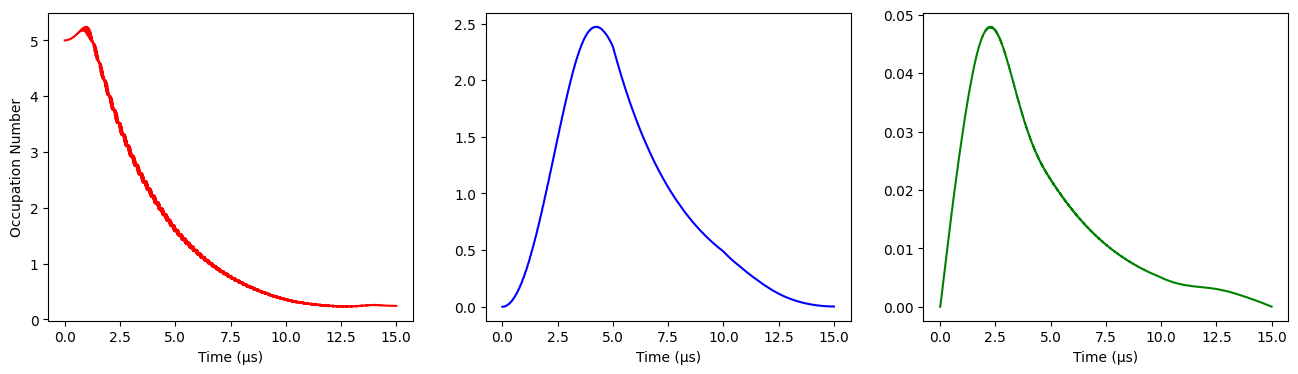

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(t_eval, result.expects[0], label='Na',color='red')
ax[1].plot(t_eval, result.expects[1], label='Nb',color='blue')
ax[2].plot(t_eval, result.expects[2], label='Nc',color='green')
ax[0].set_xlabel('Time (µs)')
ax[1].set_xlabel('Time (µs)')
ax[2].set_xlabel('Time (µs)')
ax[0].set_ylabel('Occupation Number')

print("Final Occupation Numbers:")
print(f"Na: {result.expects[0][-1]:.4f}")
print(f"Nb: {result.expects[1][-1]:.4f}")
print(f"Nc: {result.expects[2][-1]:.4f}")